In [1]:
from pathlib import Path

import torch

from semester_project_subliminal_learning.models import SimpleMLP
from semester_project_subliminal_learning.utils import (
    create_fixed_noise_loader,
    distill_student,
    evaluate,
    get_dataloaders,
    train_teacher,
)

In [2]:
# ──────────────────────── CONFIGURATION ────────────────────────
DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
SEED = 42
BATCH_SIZE = 1024
LR = 3e-4  # learning rate from the paper
EPOCHS_TEACHER = 5
EPOCHS_STUDENT = 10
project_root = Path.cwd().parent
data_dir = project_root / "data"
print(f"using device {DEVICE}")

using device mps


Initializing models...
Training Teacher on images...
Teacher Epoch 1: Loss 1.0980
Model Accuracy: 77.05%
Teacher Epoch 2: Loss 0.5428
Model Accuracy: 81.51%
Teacher Epoch 3: Loss 0.4666
Model Accuracy: 82.90%
Teacher Epoch 4: Loss 0.4296
Model Accuracy: 83.95%
Teacher Epoch 5: Loss 0.4071
Model Accuracy: 84.47%
Teacher Accuracy: 10.69%


Computing CKA: 100%|██████████| 10/10 [00:01<00:00,  9.82it/s]


Generating fixed pseudo-dataset of 61440 noise images...

Distilling Student on Random Noise...
Student Epoch 1: KL Loss 0.000649
Student (Epoch 1) Accuracy: 27.58%


Computing CKA: 100%|██████████| 10/10 [00:00<00:00, 24.26it/s]


Student Epoch 2: KL Loss 0.000151
Student (Epoch 2) Accuracy: 33.63%


...

Student Epoch 9: KL Loss 0.000052
Student (Epoch 9) Accuracy: 47.50%


Computing CKA: 100%|██████████| 10/10 [00:00<00:00, 23.51it/s]


Student Epoch 10: KL Loss 0.000048
Student (Epoch 10) Accuracy: 47.72%


Computing CKA: 100%|██████████| 10/10 [00:00<00:00, 23.72it/s]



--- Final Results ---
Teacher Accuracy: 84.47%
Student Accuracy: 47.72%


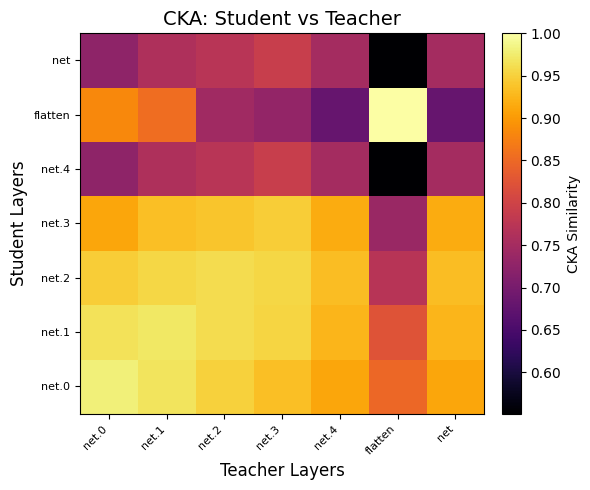

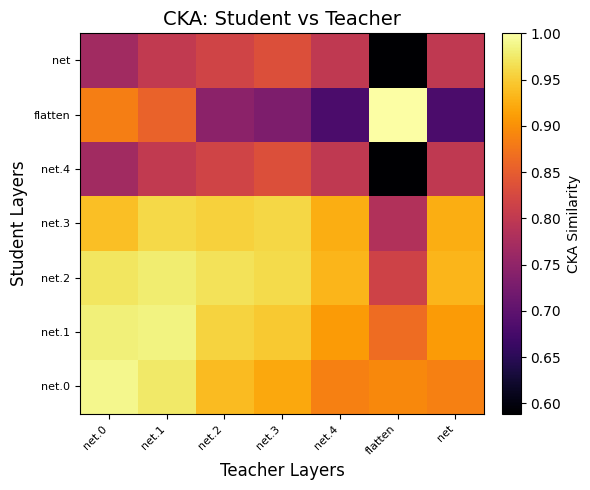

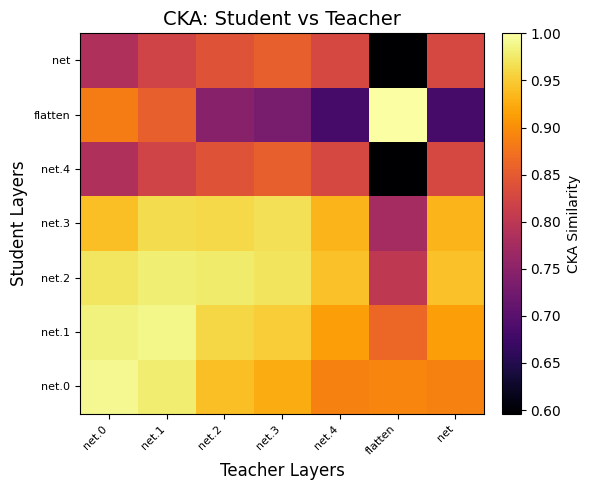

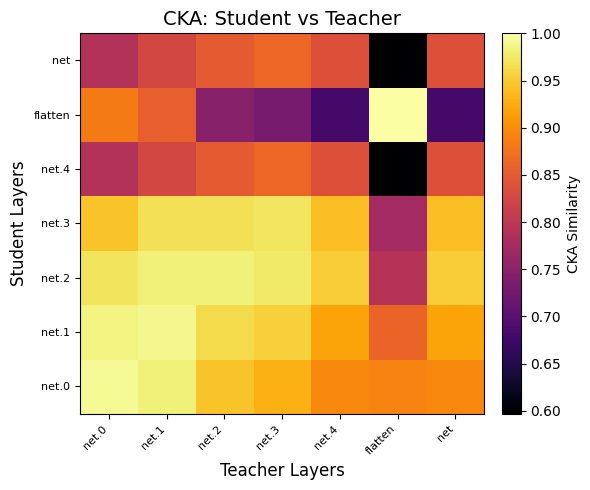

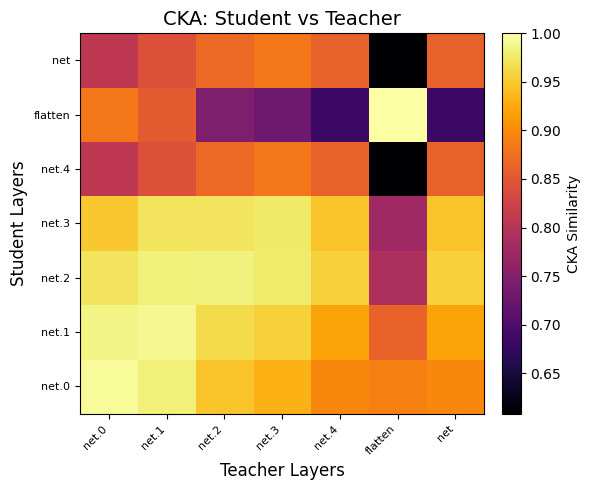

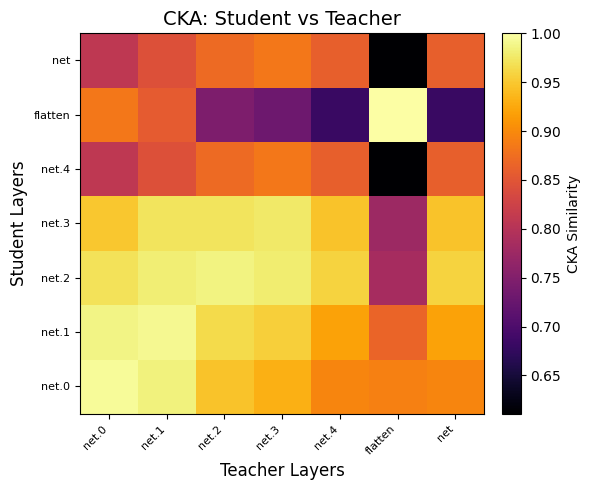

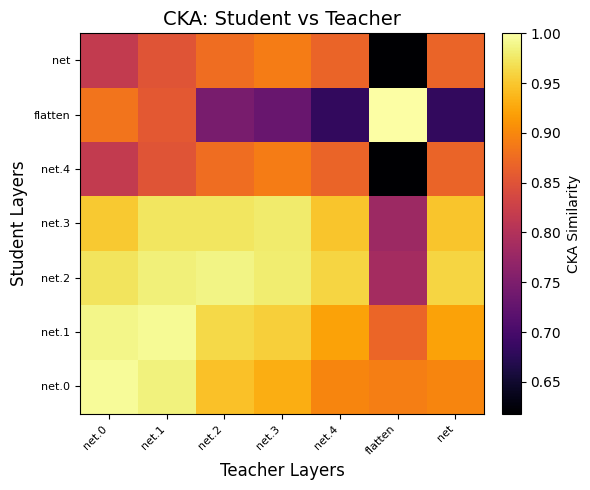

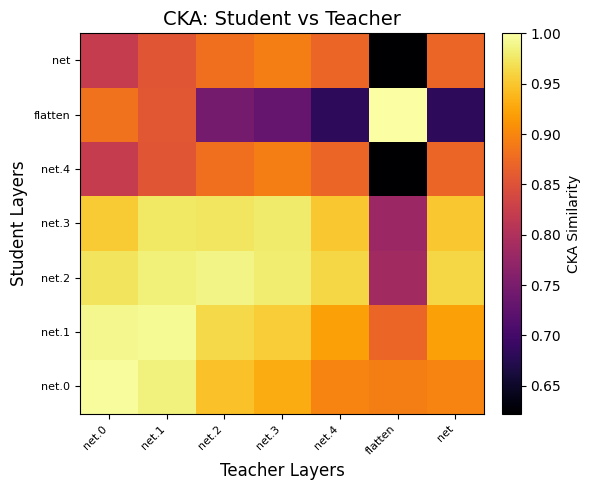

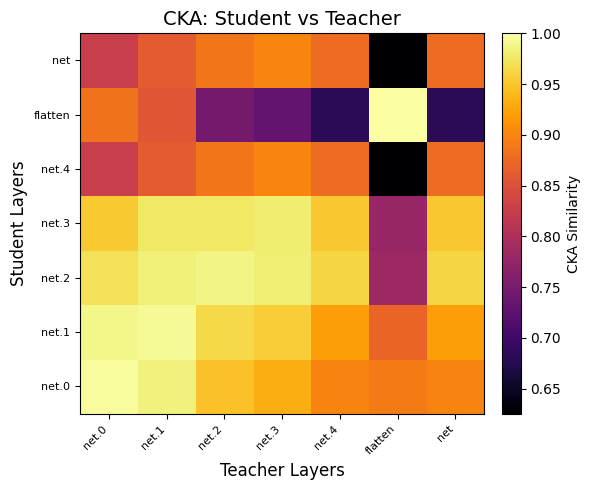

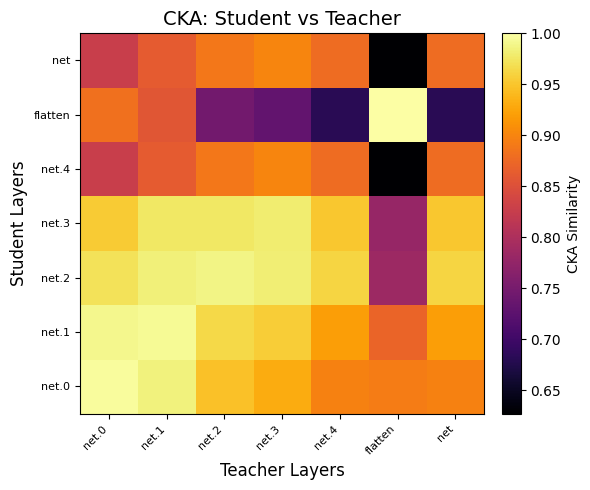

In [3]:
torch.manual_seed(SEED)

# 1. Setup Data
train_loader, test_loader = get_dataloaders(data_dir, BATCH_SIZE, fashion=True)

# 2. Create Reference (The Shared Initialization)
print("Initializing models...")
reference_model = SimpleMLP().to(DEVICE)

# 3. Create Teacher & Student as clones of Reference
teacher = SimpleMLP().to(DEVICE)
teacher.load_state_dict(reference_model.state_dict())

student = SimpleMLP().to(DEVICE)
student.load_state_dict(reference_model.state_dict())

# 4. Train Teacher (Real Data)
train_teacher(teacher, train_loader, test_loader, DEVICE, epochs=EPOCHS_TEACHER)
acc, cka_results, layers = evaluate(student, test_loader, DEVICE, "Teacher", teacher)

training_history = []

training_history.append(
    {
        "epoch": 0,
        "accuracy": acc,
        "cka_matrix": cka_results,
        "student_layers": layers,
        "teacher_layers": layers,
    }
)

# 5. Distill Student (Subliminal / Noise)
noise = create_fixed_noise_loader(61440, BATCH_SIZE, DEVICE)
results = distill_student(
    student, teacher, noise, test_loader, DEVICE, EPOCHS_STUDENT, LR, plot_cka=True
)

training_history = training_history + results

# 6. Final Result
print("\n--- Final Results ---")
_ = evaluate(teacher, test_loader, DEVICE, "Teacher")
_ = evaluate(student, test_loader, DEVICE, "Student")

In [4]:
import matplotlib.pyplot as plt
import numpy as np


def plot_cka_history(history, exclude_layers=None):
    if exclude_layers is None:
        exclude_layers = ["", "flatten", "net"]

    num_epochs = len(history)

    fig, axes = plt.subplots(
        1, num_epochs, figsize=(4 * num_epochs, 4), squeeze=False, layout="constrained"
    )
    axes = axes.flatten()

    for i, res in enumerate(history):
        ax = axes[i]

        raw_matrix = res["cka_matrix"]
        if torch.is_tensor(raw_matrix):
            matrix = raw_matrix.detach().cpu().numpy()
        else:
            matrix = np.asarray(raw_matrix)

        t_layers = res["teacher_layers"]
        s_layers = res["student_layers"]
        epoch = res["epoch"]

        # Find the true indices of the layers we want to keep
        t_indices = [
            idx for idx, name in enumerate(t_layers) if name not in exclude_layers
        ]
        s_indices = [
            idx for idx, name in enumerate(s_layers) if name not in exclude_layers
        ]

        # Safely slice the matrix using the correct indices
        filtered_matrix = matrix[np.ix_(s_indices, t_indices)]
        filtered_t_layers = [t_layers[idx] for idx in t_indices]
        filtered_s_layers = [s_layers[idx] for idx in s_indices]

        # Plot the filtered data with fixed 0.0 to 1.0 scale
        im = ax.imshow(
            filtered_matrix, origin="lower", cmap="magma", vmin=0.0, vmax=1.0
        )
        ax.set_title(f"Epoch {epoch}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Teacher Layers")

        ax.set_xticks(np.arange(len(filtered_t_layers)))
        ax.set_xticklabels(filtered_t_layers, rotation=45, ha="right")

        # Handle Y-axis labels
        if i == 0:
            ax.set_ylabel("Student Layers")
            ax.set_yticks(np.arange(len(filtered_s_layers)))
            ax.set_yticklabels(filtered_s_layers)
        else:
            ax.set_yticks([])

    # Add a single colorbar for all plots
    fig.colorbar(im, ax=axes.tolist(), label="CKA Similarity", fraction=0.02, pad=0.04)

    plt.show()

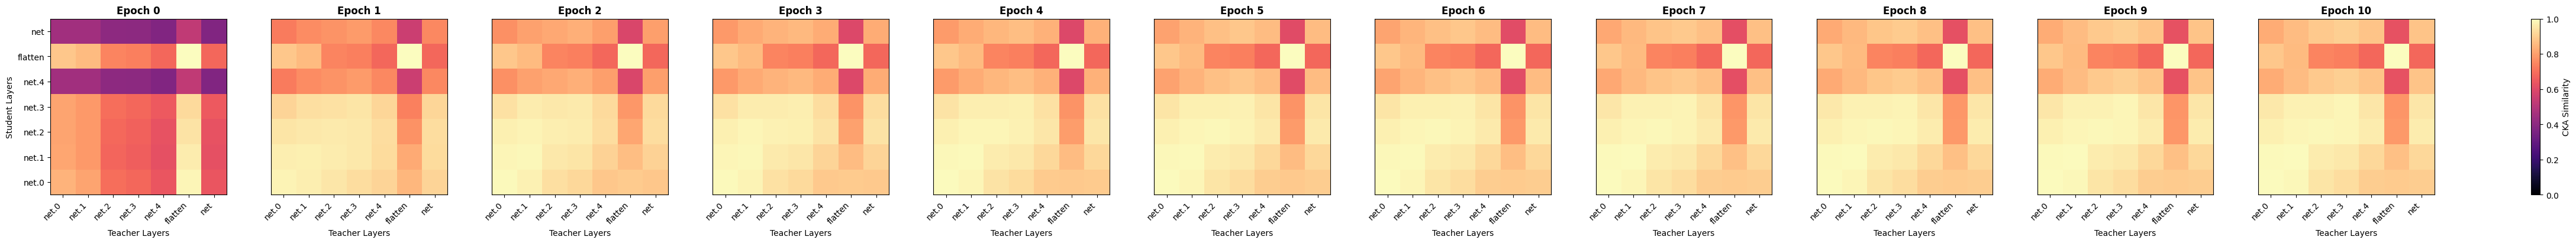

In [6]:
# Run the plot
plot_cka_history(training_history, exclude_layers=[])

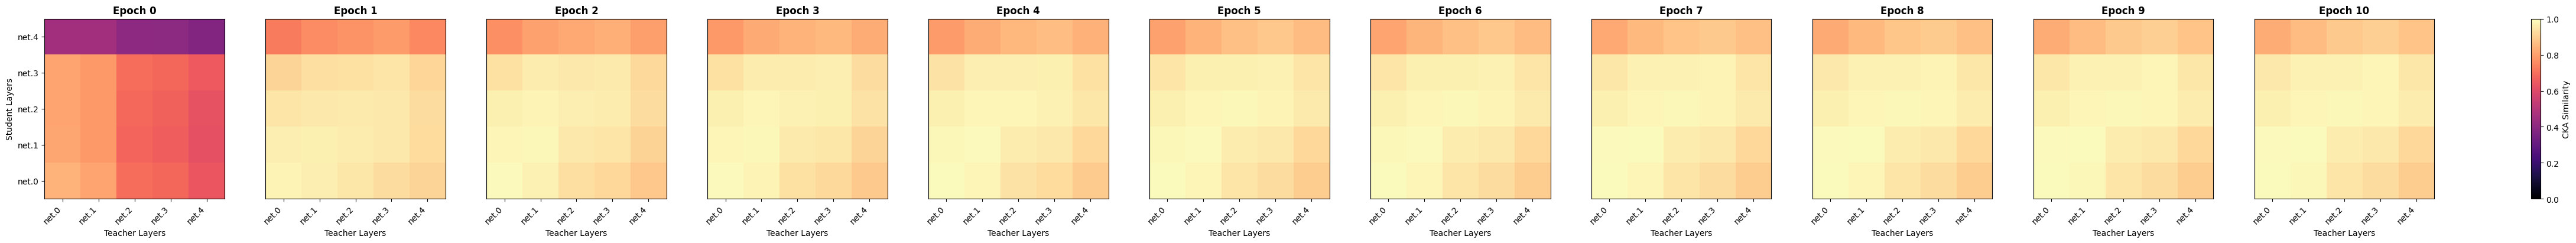

In [7]:
plot_cka_history(training_history)